# Static analysis of  apartments data

In [186]:
from __future__ import annotations

from pathlib import Path
import duckdb
import pandas as pd
import matplotlib.pyplot as plt

In [188]:
import importlib
from apartments import viz
importlib.reload(viz)

from apartments.viz import (
    build_view,
    plot_hist,
    plot_box,
    plot_scatter,
    plot_box_by_category
)

In [46]:
PROJECT_ROOT = Path("..").resolve()  # notebooks/ -> project root
DB_PATH = PROJECT_ROOT / "data" / "processed" / "apartments.duckdb"

**Basic plotting defaults**

In [47]:
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True

Connect to DuckDB 

In [ ]:
'''
if not DB_PATH.exists():
    raise FileNotFoundError(f"DuckDB file not found: {DB_PATH}")

# Close any existing connection first
try:
    con.close()
except:
    pass

# Rebuild dataset and DB with Unicode support
import subprocess, os
env = os.environ.copy()
env["PYTHONIOENCODING"] = "utf-8"

result = subprocess.run(
    ["python", "scripts/build_dataset.py"],
    cwd=str(PROJECT_ROOT),
    capture_output=True,
    text=True,
    env=env
)
if result.returncode == 0:
    print("build_dataset.py: OK")
else:
    print("build_dataset.py ERROR:", result.stderr[:500])

result = subprocess.run(
    ["python", "scripts/build_db.py"],
    cwd=str(PROJECT_ROOT),
    capture_output=True,
    text=True
)
print(result.stdout)
if result.returncode != 0:
    print("ERROR:", result.stderr)

# Now connect
'''
con = duckdb.connect(str(DB_PATH), read_only=True)

build_dataset.py: OK
QA: [('rent', 20340, 0, 0, 0), ('sale', 43691, 0, 0, 0)]
Built DuckDB at: C:\Users\tymot\OneDrive\Dokumenty\apartments_prices\data\processed\apartments.duckdb



In [177]:
# Final verification: Check integer columns in loaded data
print("Final Data Quality Check:")
print("\ndf_view (clipped to P1-P99) sample:")
for col in INT_COLS:
    null_count = df_view[col].isna().sum()
    min_val = df_view[col].min()
    max_val = df_view[col].max()
    print(f"  {col}: NaNs={null_count:,}, min={min_val:.0f}, max={max_val:.0f}")

print("\ndf_static (full dataset) sample:")
for col in INT_COLS:
    null_count = df_static[col].isna().sum()
    min_val = df_static[col].min()
    max_val = df_static[col].max()
    print(f"  {col}: NaNs={null_count:,}, min={min_val:.0f}, max={max_val:.0f}")

print("\n✓ All sentinel values successfully removed and converted to NaN")

Final Data Quality Check:

df_view (clipped to P1-P99) sample:
  rooms: NaNs=0, min=1, max=6
  floor: NaNs=3,208, min=1, max=29
  floors_total: NaNs=91, min=1, max=29
  build_year: NaNs=1,218, min=1851, max=2024

df_static (full dataset) sample:
  rooms: NaNs=0, min=1, max=6
  floor: NaNs=3,208, min=1, max=29
  floors_total: NaNs=91, min=1, max=29
  build_year: NaNs=1,218, min=1851, max=2024

✓ All sentinel values successfully removed and converted to NaN


In [49]:
# Quick sanity: list tables/views available
tables = con.execute("SHOW ALL TABLES;").fetchdf()
print("Available tables/views:")
display(tables)

Available tables/views:


,database,schema,name,column_names,column_types,temporary
0,apartments,main,listings_all,"[listing_id, city, listing_type, area_m2, room...","[VARCHAR, VARCHAR, VARCHAR, DOUBLE, BIGINT, VA...",False
1,apartments,main,listings_rent,"[listing_id, city, listing_type, area_m2, room...","[VARCHAR, VARCHAR, VARCHAR, DOUBLE, BIGINT, VA...",False
2,apartments,main,listings_rent_static,"[listing_id, city, listing_type, area_m2, room...","[VARCHAR, VARCHAR, VARCHAR, DOUBLE, BIGINT, VA...",False
3,apartments,main,listings_sale,"[listing_id, city, listing_type, area_m2, room...","[VARCHAR, VARCHAR, VARCHAR, DOUBLE, BIGINT, VA...",False
4,apartments,main,listings_sale_static,"[listing_id, city, listing_type, area_m2, room...","[VARCHAR, VARCHAR, VARCHAR, DOUBLE, BIGINT, VA...",False
5,apartments,main,listings_static_all,"[listing_id, city, listing_type, area_m2, room...","[VARCHAR, VARCHAR, VARCHAR, DOUBLE, BIGINT, VA...",False
6,apartments,main,mart_city_month_rent,"[month, city, n_listings, median_ppm2, p25_ppm...","[TIMESTAMP, VARCHAR, BIGINT, DOUBLE, DOUBLE, D...",False
7,apartments,main,mart_city_month_sale,"[month, city, n_listings, median_ppm2, p25_ppm...","[TIMESTAMP, VARCHAR, BIGINT, DOUBLE, DOUBLE, D...",False
8,apartments,main,mart_city_month_yield_proxy,"[month, city, n_sale, n_rent, sale_median_ppm2...","[TIMESTAMP, VARCHAR, BIGINT, BIGINT, DOUBLE, D...",False


Construction of static database snapshot

In [174]:
QUERY_STATIC = """
SELECT
    *
FROM listings_sale_static
"""

df_static = con.execute(QUERY_STATIC).fetchdf()

print(f"Static snapshot loaded.")
print(f"Number of properties (static): {len(df_static):,}")

display(df_static.head())

Static snapshot loaded.
Number of properties (static): 21,991


,listing_id,city,listing_type,area_m2,lat,lon,centre_distance,poi_count,school_distance,clinic_distance,...,district,lat_r,lon_r,area_q,property_fingerprint,price_per_m2,rooms,floor,floors_total,build_year
0,1f1dc66657e4d934a348afa8dac650cb,warszawa,apartmentBuilding,48.00,52.257800,20.969213,3.73,32.0,0.319,0.243,...,żoliborz,52.2578,20.9692,48.0,52.2578|20.9692|48.0|sale|warszawa|apartmentBu...,24500.000000,2,6,6,2014
1,879159b7454952a8b05ffb72f4964fd7,warszawa,apartmentBuilding,88.00,52.257785,20.973452,3.55,32.0,0.238,0.119,...,żoliborz,52.2578,20.9735,88.0,52.2578|20.9735|88.0|sale|warszawa|apartmentBu...,23295.454545,3,4,6,2013
2,4bad1db8d41324dc275b70a22b0482d8,warszawa,blockOfFlats,57.00,52.257790,21.055050,4.55,21.0,0.107,0.206,...,praga_północ,52.2578,21.055,57.0,52.2578|21.055|57.0|sale|warszawa|blockOfFlats...,14000.000000,3,9,10,1974
3,62d7c3a70a7a25e6ed7e10aac5b9f387,warszawa,apartmentBuilding,43.19,52.257853,20.966824,3.83,30.0,0.319,0.179,...,żoliborz,52.2579,20.9668,43.0,52.2579|20.9668|43.0|sale|warszawa|apartmentBu...,23153.507756,2,1,7,2022
4,2a6a5b2b0f6b8a2277859ea843b55c0d,warszawa,blockOfFlats,64.90,52.258179,20.924788,6.12,14.0,0.146,0.377,...,bemowo,52.2582,20.9248,65.0,52.2582|20.9248|65.0|sale|warszawa|blockOfFlat...,9167.950693,3,7,10,1981


In [51]:
print(df_static.columns)

Index(['listing_id', 'city', 'listing_type', 'area_m2', 'rooms', 'floor',
       'floors_total', 'build_year', 'lat', 'lon', 'centre_distance',
       'poi_count', 'school_distance', 'clinic_distance',
       'post_office_distance', 'kindergarten_distance', 'restaurant_distance',
       'college_distance', 'pharmacy_distance', 'ownership',
       'building_material', 'condition', 'has_parking_space', 'has_balcony',
       'has_elevator', 'has_security', 'has_storage_room', 'price', 'month',
       'market', 'district', 'lat_r', 'lon_r', 'area_q',
       'property_fingerprint', 'price_per_m2'],
      dtype='object')


In [52]:
df_static.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21991 entries, 0 to 21990
Data columns (total 36 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   listing_id             21991 non-null  object        
 1   city                   21991 non-null  object        
 2   listing_type           21991 non-null  object        
 3   area_m2                21991 non-null  float64       
 4   rooms                  21991 non-null  int64         
 5   floor                  21991 non-null  object        
 6   floors_total           21991 non-null  object        
 7   build_year             21991 non-null  object        
 8   lat                    21991 non-null  float64       
 9   lon                    21991 non-null  float64       
 10  centre_distance        21991 non-null  float64       
 11  poi_count              21991 non-null  float64       
 12  school_distance        21989 non-null  float64       
 13  c

In [53]:
district_coverage = (
    df_static
    .groupby("district", dropna=False)
    .size()
    .sort_values(ascending=False)
    .reset_index(name="n_listings")
)

display(district_coverage)

,district,n_listings
0,mokotów,3445
1,wola,2410
2,praga_południe,2134
3,śródmieście,1957
4,białołęka,1647
5,ursynów,1514
6,bielany,1334
7,bemowo,1281
8,ochota,1071
9,targówek,961


In [54]:

df_static = df_static.dropna(subset=["district"]).copy()
print(len(df_static))

21976


In [55]:
(df_static.isna()
          .sum()
          .sort_values(ascending=False))

condition                15893
building_material         7209
college_distance           515
clinic_distance            100
restaurant_distance         85
pharmacy_distance           45
kindergarten_distance       22
post_office_distance        17
school_distance              2
district                     0
market                       0
month                        0
price                        0
has_storage_room             0
has_parking_space            0
lat_r                        0
lon_r                        0
area_q                       0
has_elevator                 0
has_balcony                  0
property_fingerprint         0
has_security                 0
listing_id                   0
ownership                    0
city                         0
poi_count                    0
centre_distance              0
lon                          0
lat                          0
build_year                   0
floors_total                 0
floor                        0
rooms   

In [56]:
(df_static.isna()
          .mean()
          .mul(100)
          .round(2)
          .sort_values(ascending=False))

condition                72.32
building_material        32.80
college_distance          2.34
clinic_distance           0.46
restaurant_distance       0.39
pharmacy_distance         0.20
kindergarten_distance     0.10
post_office_distance      0.08
school_distance           0.01
district                  0.00
market                    0.00
month                     0.00
price                     0.00
has_storage_room          0.00
has_parking_space         0.00
lat_r                     0.00
lon_r                     0.00
area_q                    0.00
has_elevator              0.00
has_balcony               0.00
property_fingerprint      0.00
has_security              0.00
listing_id                0.00
ownership                 0.00
city                      0.00
poi_count                 0.00
centre_distance           0.00
lon                       0.00
lat                       0.00
build_year                0.00
floors_total              0.00
floor                     0.00
rooms   

In [57]:
df_static[["price", "price_per_m2", "area_m2"]].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99])

,price,price_per_m2,area_m2
count,2.197600e+04,21976.000000,21976.000000
mean,9.796363e+05,17273.760600,57.282902
std,4.360405e+05,4090.696992,21.251521
min,3.000000e+05,7000.000000,25.000000
1%,4.490000e+05,9715.801057,26.565000
5%,5.390000e+05,11524.706597,31.000000
50%,8.500000e+05,16831.077272,53.100000
95%,1.895000e+06,25000.000000,100.025000
99%,2.570900e+06,28947.368421,128.485000
max,3.250000e+06,31041.666667,150.000000


In [58]:
df_static.dtypes

listing_id                       object
city                             object
listing_type                     object
area_m2                         float64
rooms                             int64
floor                            object
floors_total                     object
build_year                       object
lat                             float64
lon                             float64
centre_distance                 float64
poi_count                       float64
school_distance                 float64
clinic_distance                 float64
post_office_distance            float64
kindergarten_distance           float64
restaurant_distance             float64
college_distance                float64
pharmacy_distance               float64
ownership                        object
building_material                object
condition                        object
has_parking_space                object
has_balcony                      object
has_elevator                     object


In [59]:
categorical_cols = [
    "listing_type",
    "ownership",
    "building_material",
    "condition",
    "district",
]

In [60]:
for col in categorical_cols:
    print(f"\n=== {col} ===")
    if col not in df_static.columns:
        print("Column not found")
        continue

    display(
        df_static[col]
        .value_counts(dropna=False)
        .rename("count")
        .to_frame()
    )


=== listing_type ===


,count
listing_type,
blockOfFlats,13096
apartmentBuilding,5847
tenement,3033



=== ownership ===


,count
ownership,
condominium,19170
cooperative,2806



=== building_material ===


,count
building_material,
brick,11635
None,7209
concreteSlab,3132



=== condition ===


,count
condition,
None,15893
premium,3492
low,2591



=== district ===


,count
district,
mokotów,3445
wola,2410
praga_południe,2134
śródmieście,1957
białołęka,1647
ursynów,1514
bielany,1334
bemowo,1281
ochota,1071


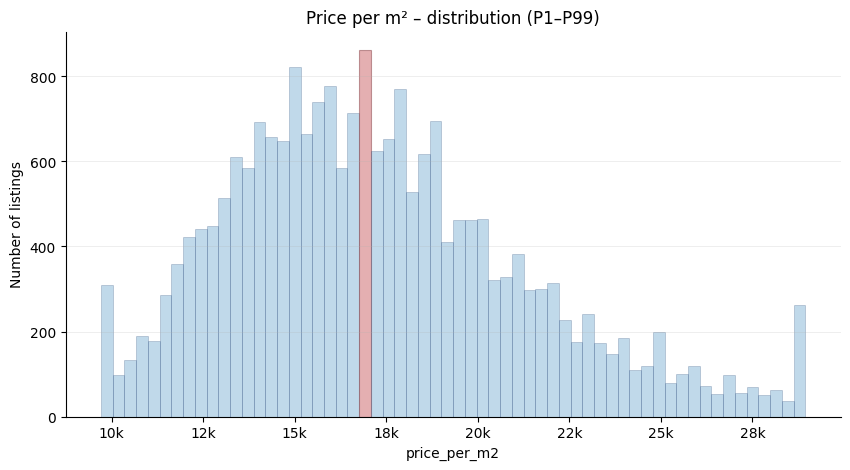

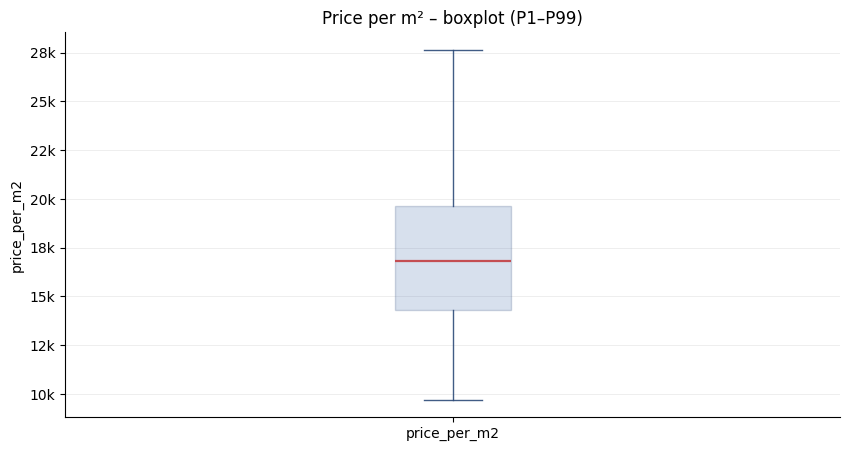

In [175]:
df_view, bounds = build_view(
    df_static,
    clip_cols=["price_per_m2", "price", "area_m2"],
    clip=True,
)

plot_hist(
    df_view,
    "price_per_m2",
    bounds=bounds,
    bins=60,
    title="Price per m² – distribution (P1–P99)",
    median_mode="bin",
)

plot_box(
    df_view,
    "price_per_m2",
    bounds=bounds,
    title="Price per m² – boxplot (P1–P99)",
)


Skipping None - too few listings (0)


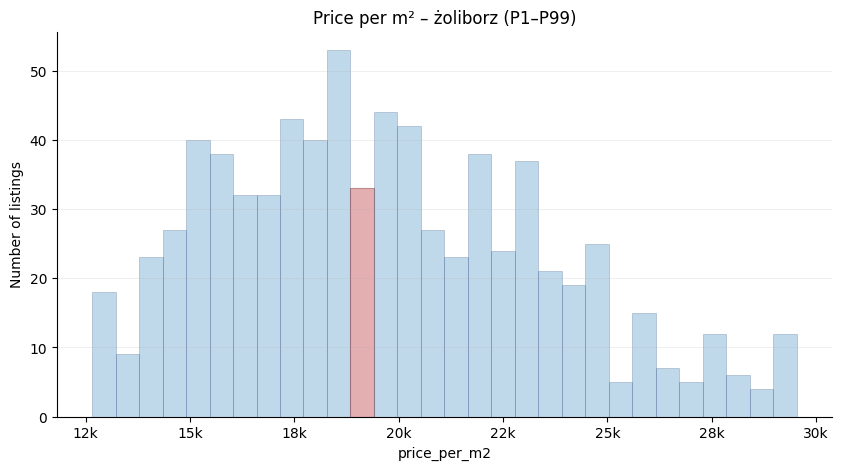

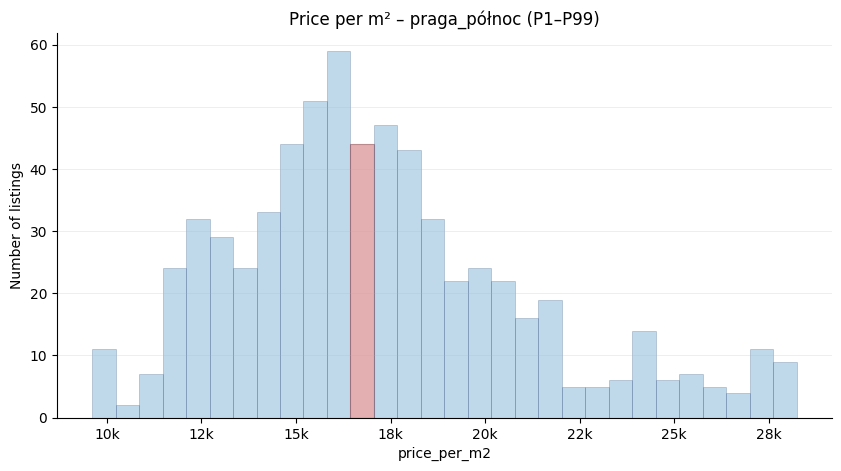

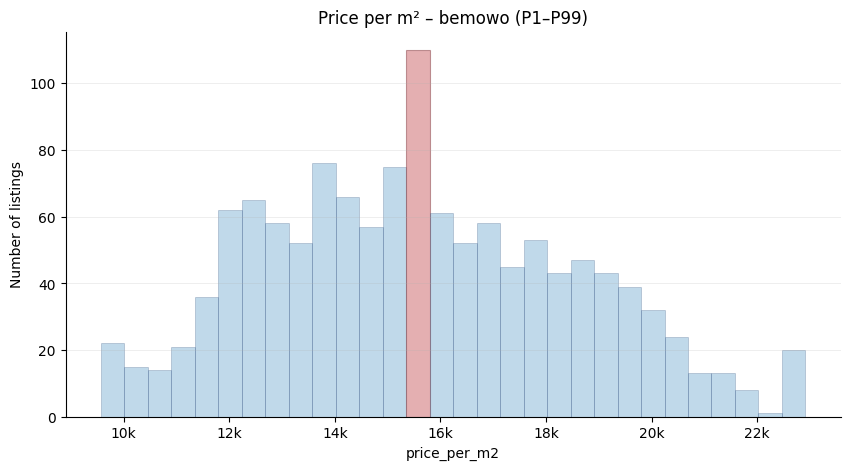

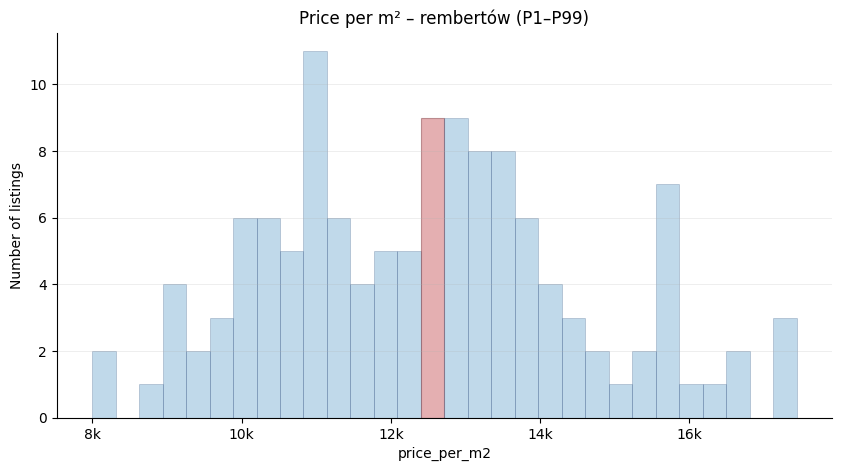

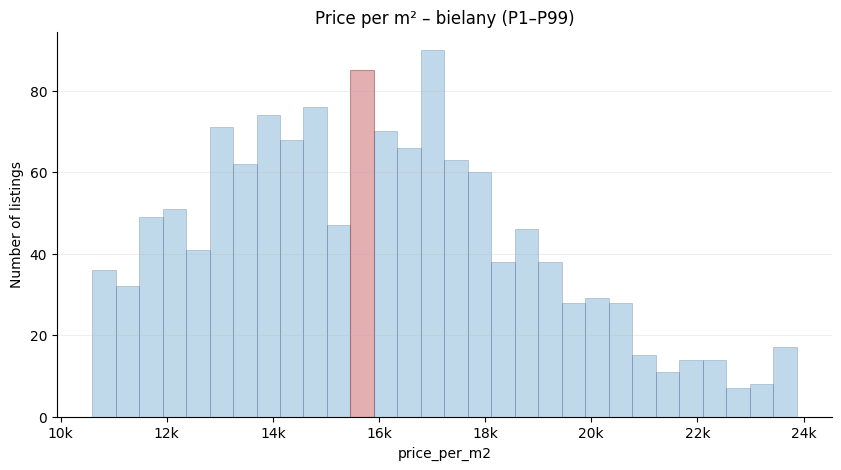

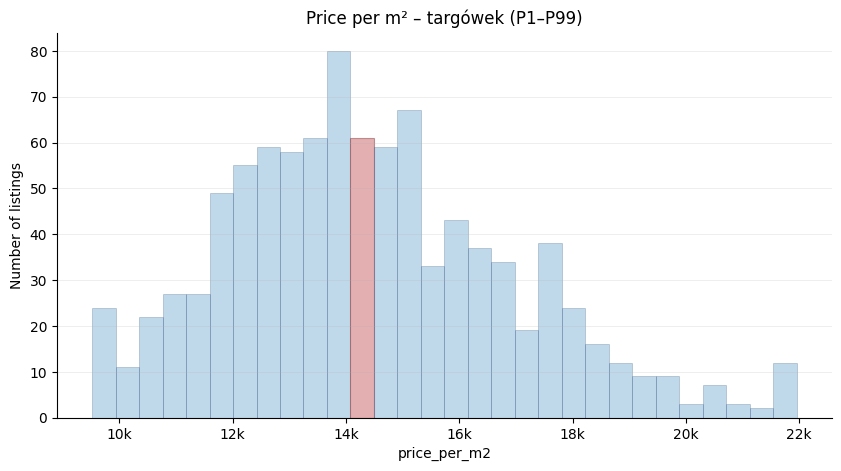

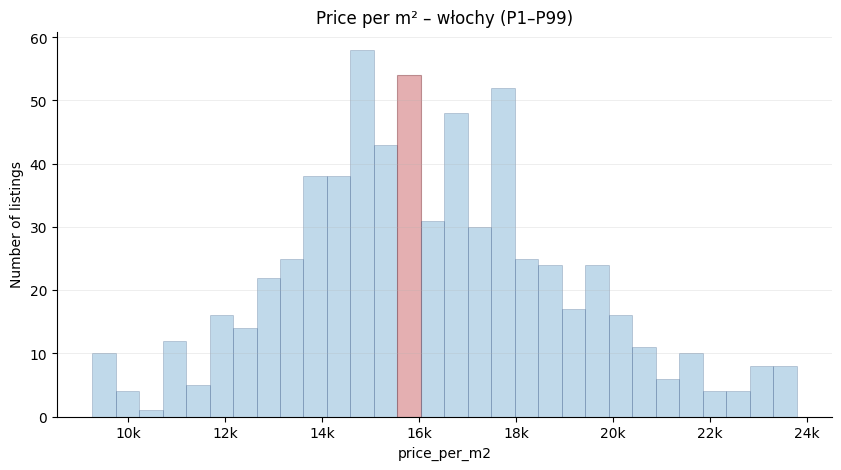

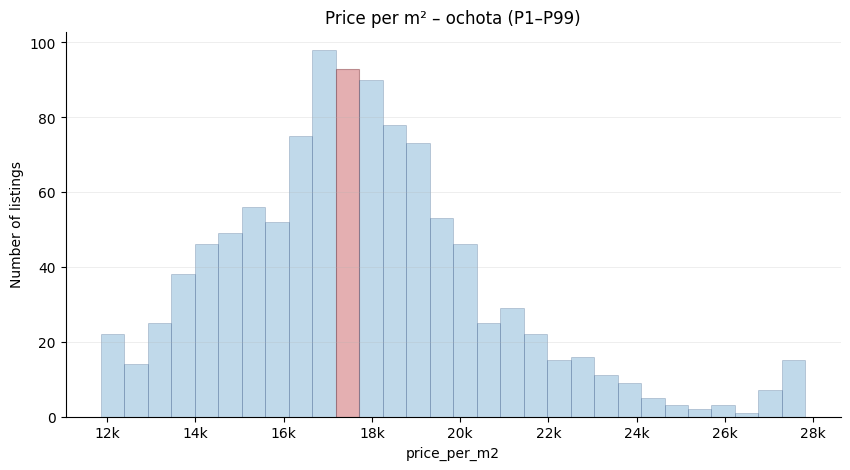

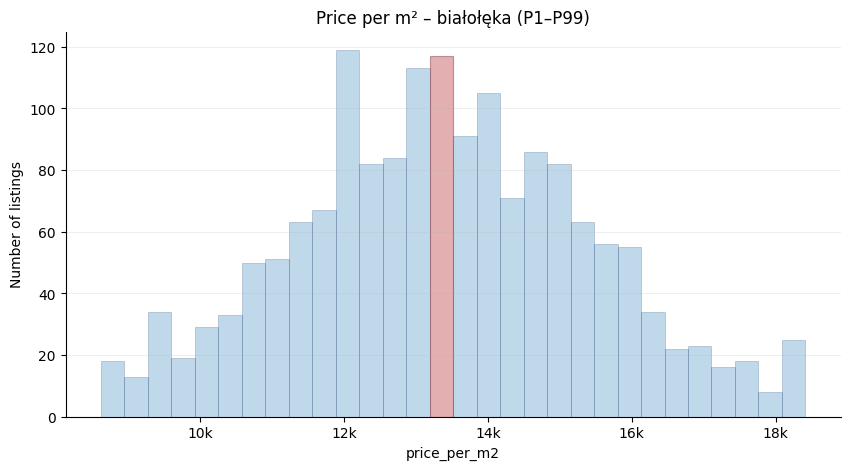

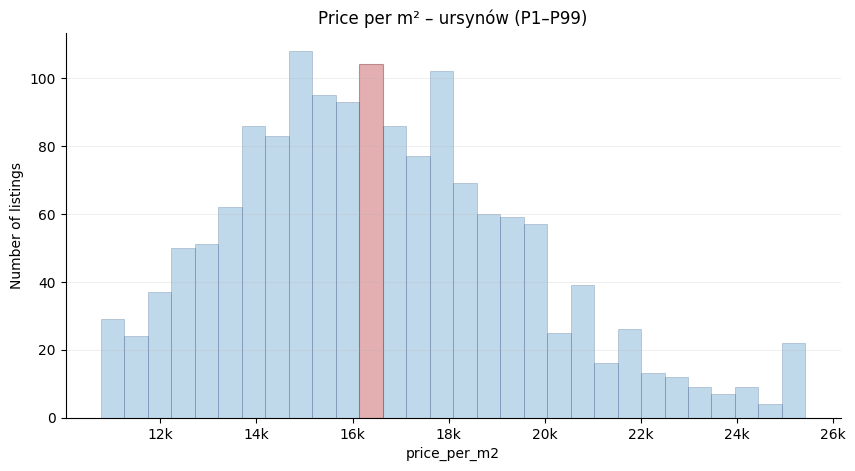

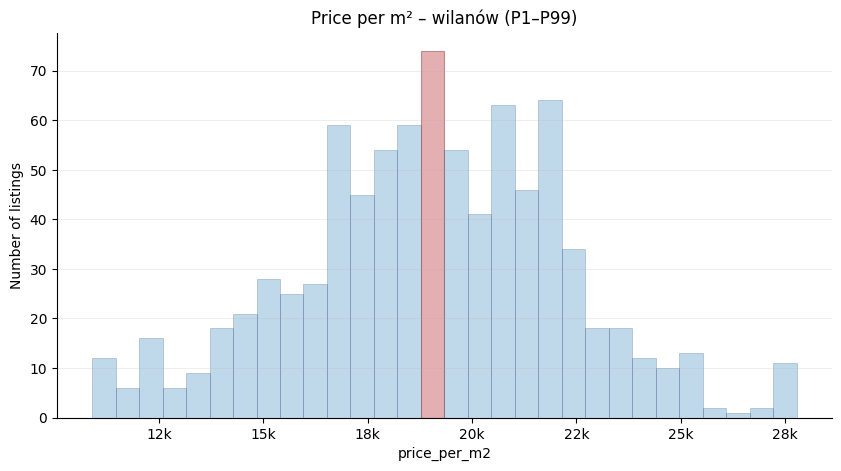

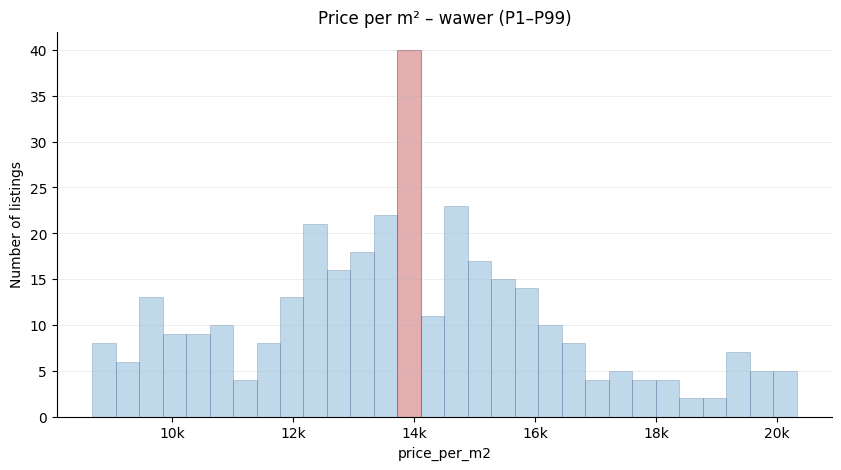

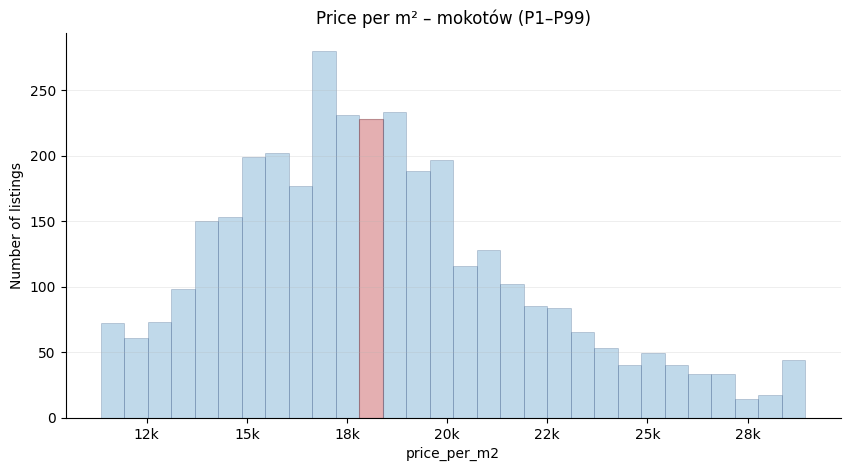

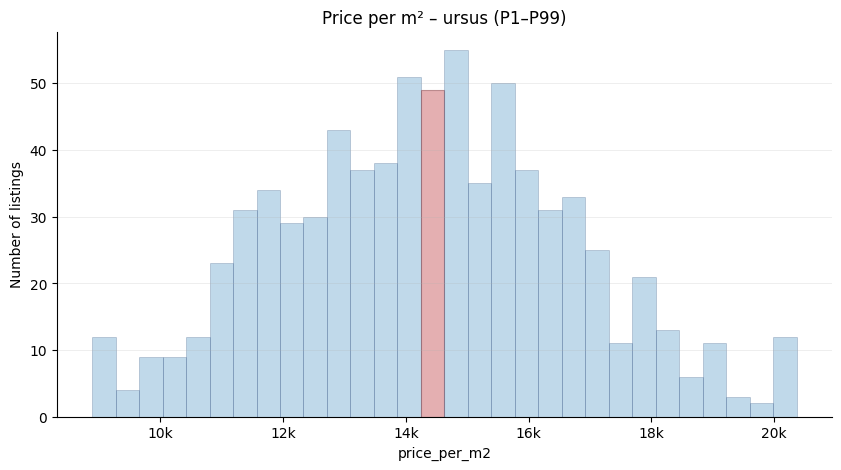

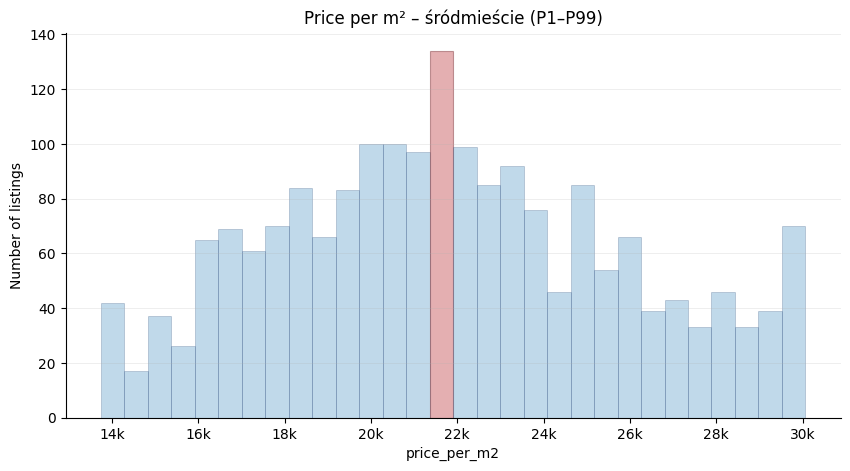

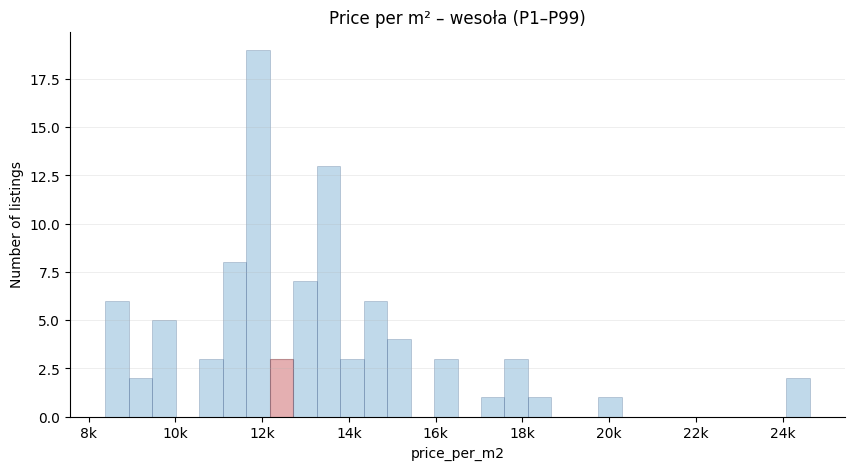

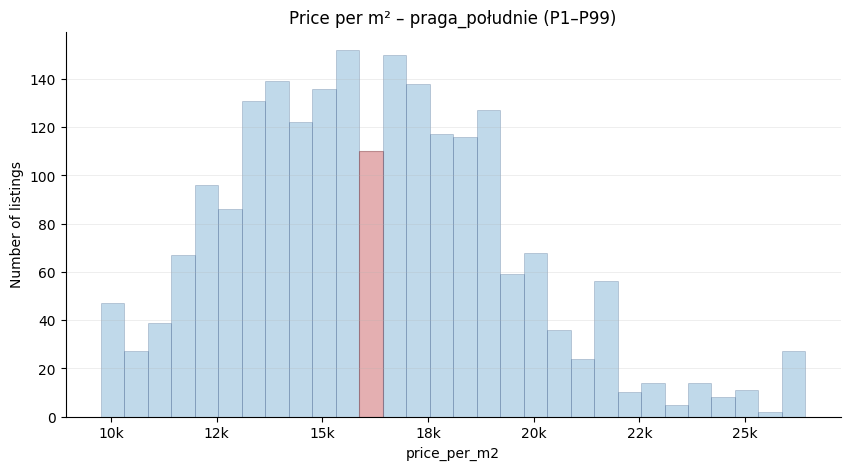

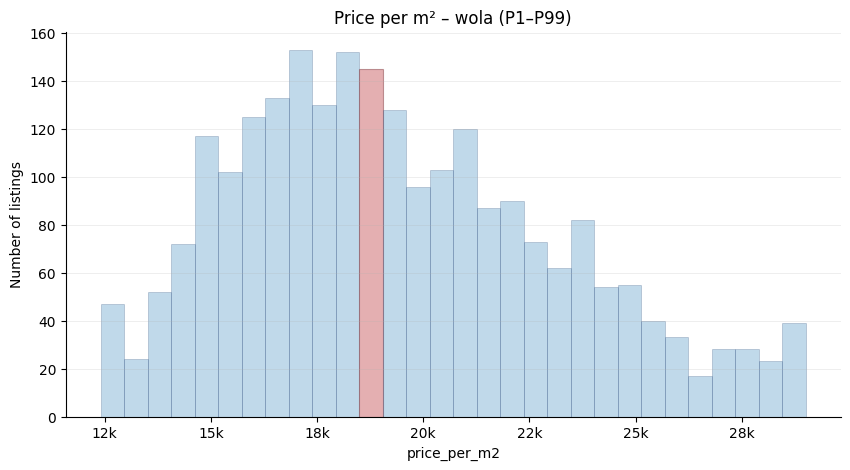

In [138]:
for district_name in df_static['district'].unique():
    df_district = df_static[df_static['district'] == district_name].copy()
    
    if len(df_district) < 10:
        print(f"Skipping {district_name} - too few listings ({len(df_district)})")
        continue
    
    df_district_view, district_bounds = build_view(
        df_district,
        clip_cols=["price_per_m2"],
        clip=True,
    )
    
    plot_hist(
        df_district_view,
        "price_per_m2",
        bounds=district_bounds,
        bins=30,
        title=f"Price per m² – {district_name} (P1–P99)",
        median_mode="bin",
    )

In [ ]:
g = df_view.groupby("district")["price_per_m2"]

rank_district = (
    pd.DataFrame({
        "n": g.size(),
        "median_ppm2": g.median(),
        "p25_ppm2": g.quantile(0.25),
        "p75_ppm2": g.quantile(0.75),
        "mean_ppm2": g.mean(),
    })
    .assign(iqr_ppm2=lambda x: x["p75_ppm2"] - x["p25_ppm2"])
    .sort_values(["median_ppm2", "n"], ascending=[False, False])
)

rank_district

,n,median_ppm2,p25_ppm2,p75_ppm2,mean_ppm2,iqr_ppm2
district,,,,,,
śródmieście,1957,21540.469974,18774.703557,24833.333333,21811.912619,6058.629776
żoliborz,754,19138.765966,16636.595694,22330.634901,19615.039702,5694.039208
wilanów,848,19011.993383,16926.838443,21212.121212,19030.932436,4285.282769
wola,2410,18898.717949,16519.688853,21958.234145,19418.449681,5438.545292
mokotów,3445,17868.538609,15617.977528,20312.500000,18300.315078,4694.522472
ochota,1071,17570.093458,15784.687081,19212.787213,17753.753567,3428.100132
praga_północ,657,16645.065729,14680.788467,19184.210526,17228.704825,4503.422059
ursynów,1514,16330.682790,14444.489096,18492.590286,16608.404876,4048.101190
praga_południe,2134,15993.265993,13809.281451,18305.892548,16239.231142,4496.611097


In [ ]:
print(df_static.columns)

Index(['listing_id', 'city', 'listing_type', 'area_m2', 'rooms', 'floor',
       'floors_total', 'build_year', 'lat', 'lon', 'centre_distance',
       'poi_count', 'school_distance', 'clinic_distance',
       'post_office_distance', 'kindergarten_distance', 'restaurant_distance',
       'college_distance', 'pharmacy_distance', 'ownership',
       'building_material', 'condition', 'has_parking_space', 'has_balcony',
       'has_elevator', 'has_security', 'has_storage_room', 'price', 'month',
       'market', 'district', 'lat_r', 'lon_r', 'area_q',
       'property_fingerprint', 'price_per_m2'],
      dtype='object')


In [140]:

# Close DB and rebuild with INTEGER casting
con.close()

result = subprocess.run(
    ["python", "scripts/build_db.py"],
    cwd=str(PROJECT_ROOT),
    capture_output=True,
    text=True
)
print(result.stdout)
if result.returncode != 0:
    print("ERROR:", result.stderr)

# Reconnect
con = duckdb.connect(str(DB_PATH), read_only=True)
print("\nReconnected to DB")

# Verify floors_total dtype is now correct
schema = con.execute("DESCRIBE listings_sale_static").fetchall()
for col_name, col_type, *rest in schema:
    if 'floor' in col_name.lower():
        print(f"{col_name} -> {col_type}")

# Reload data from fresh DB
QUERY_STATIC = """
SELECT *
FROM listings_sale_static
"""
df_static = con.execute(QUERY_STATIC).fetchdf()

print(f"\ndf_static['floors_total'].dtype: {df_static['floors_total'].dtype}")
print(f"Sample values: {df_static['floors_total'].head(10).tolist()}")


QA: [('rent', 20340, 0, 0, 0), ('sale', 43691, 0, 0, 0)]
Built DuckDB at: C:\Users\tymot\OneDrive\Dokumenty\apartments_prices\data\processed\apartments.duckdb


Reconnected to DB
floor -> INTEGER
floors_total -> INTEGER

df_static['floors_total'].dtype: int32
Sample values: [6, 6, 10, 7, 10, 5, 4, 6, 4, 4]


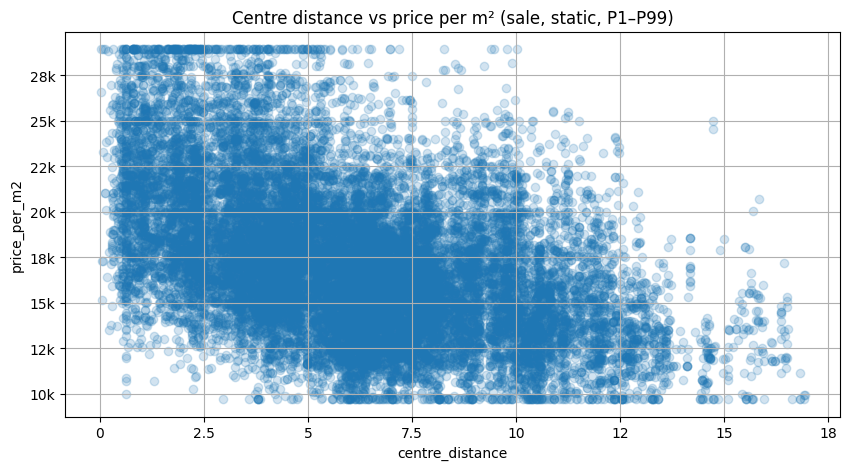

In [141]:
plt.close("all")

plot_scatter(
    df_view,
    x_col="centre_distance",
    y_col="price_per_m2",
    bounds=bounds,
    title="Centre distance vs price per m² (sale, static, P1–P99)",
)

C:\Users\tymot\OneDrive\Dokumenty\apartments_prices\src\apartments\viz.py:472: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .agg(n="size", median="median")


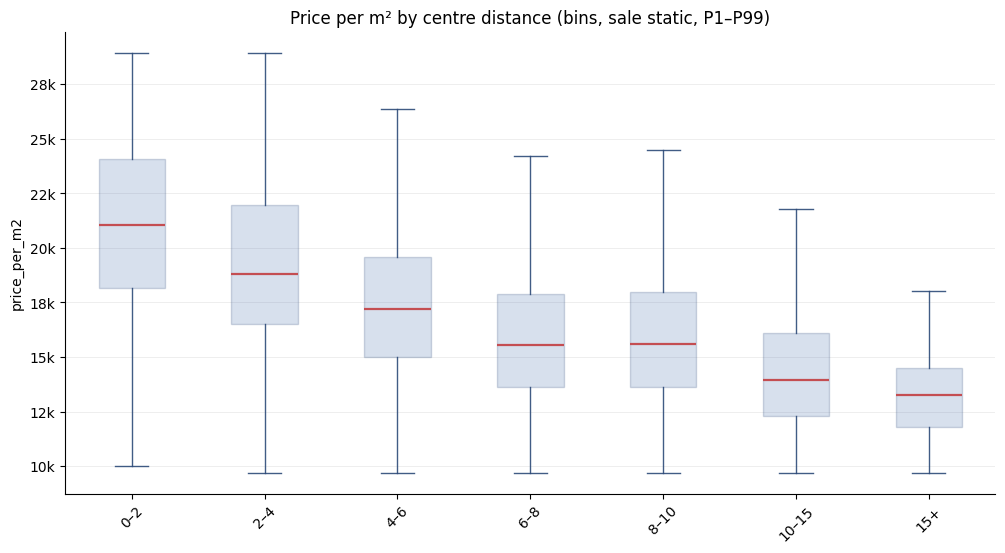

In [142]:
df_dist = df_view.copy()

# Reasonable bins for Warsaw
bins = [0, 2, 4, 6, 8, 10, 15, 25]
labels = ["0–2", "2–4", "4–6", "6–8", "8–10", "10–15", "15+"]

df_dist["centre_dist_bin"] = pd.cut(
    df_dist["centre_distance"],
    bins=bins,
    labels=labels,
    include_lowest=True,
)

plt.close("all")
plot_box_by_category(
    df_dist.dropna(subset=["centre_dist_bin"]),
    y_col="price_per_m2",
    category_col="centre_dist_bin",
    order=labels,
    bounds=bounds,
    title="Price per m² by centre distance (bins, sale static, P1–P99)",
)

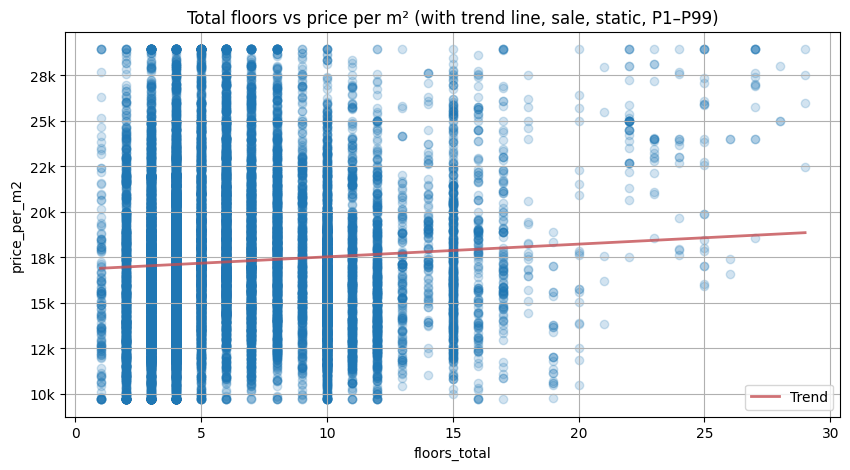

In [146]:
df_ft = df_view.copy()

df_ft = df_ft[
    df_ft["floors_total"].notna()
    & (df_ft["floors_total"] >= 1)
    & (df_ft["floors_total"] <= 60)
].copy()

plt.close("all")

plot_scatter(
    df_ft,
    x_col="floors_total",
    y_col="price_per_m2",
    bounds=bounds,
    trendline=True,
    title="Total floors vs price per m² (with trend line, sale, static, P1–P99)",
)


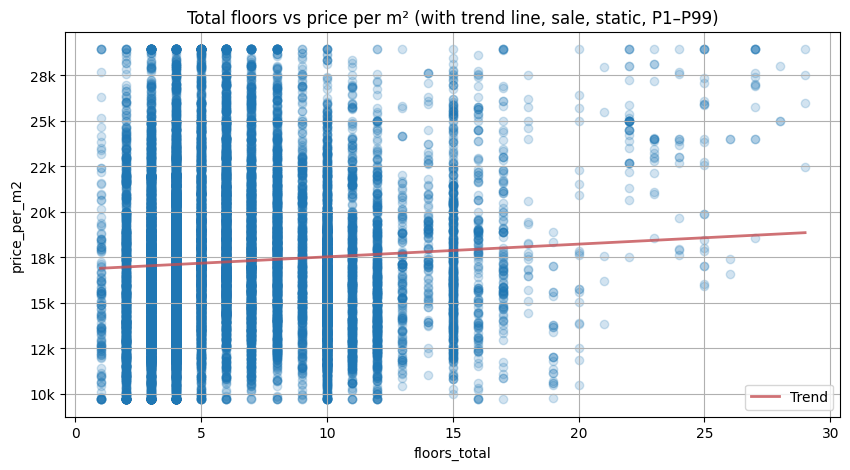

In [130]:

plt.close("all")

plot_scatter(
    df_ft,
    x_col="floors_total",
    y_col="price_per_m2",
    bounds=bounds,
    trendline=True,
    title="Total floors vs price per m² (with trend line, sale, static, P1–P99)",
)



Price statistics for both building groups:

<20 floors:
  n = 21853
  median = 16800 PLN/m²
  mean = 17234 PLN/m²
  std = 4060 PLN/m²

≥20 floors:
  n = 138
  median = 24000 PLN/m²
  mean = 23313 PLN/m²
  std = 4525 PLN/m²


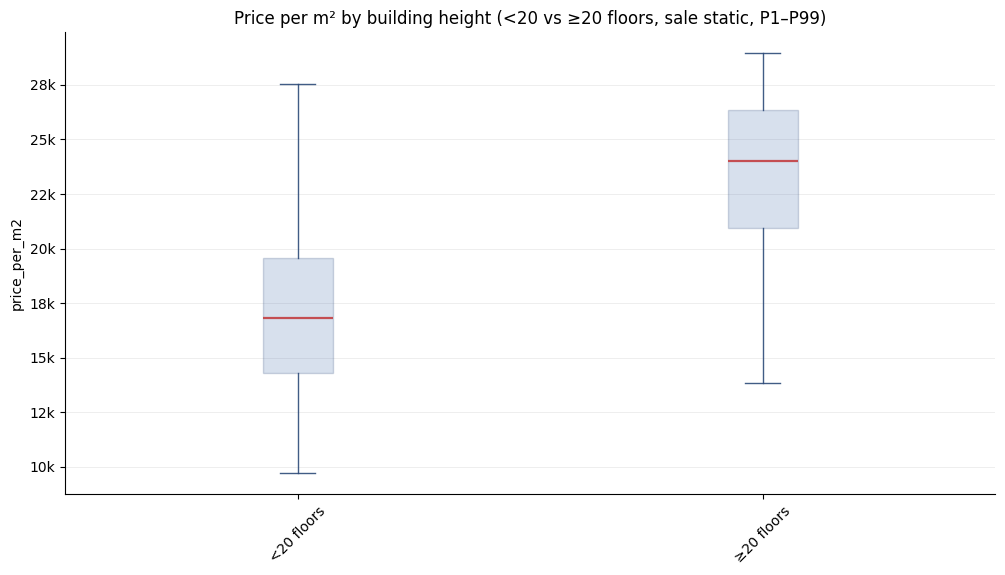

In [147]:
# Price comparison for buildings below and above 20 floors
df_height = df_view.dropna(subset=["floors_total"]).copy()

df_height["height_group"] = df_height["floors_total"].apply(
    lambda x: "<20 floors" if x < 20 else "≥20 floors"
)

plt.close("all")
plot_box_by_category(
    df_height,
    y_col="price_per_m2",
    category_col="height_group",
    order=["<20 floors", "≥20 floors"],
    bounds=bounds,
    title="Price per m² by building height (<20 vs ≥20 floors, sale static, P1–P99)",
)

# Price statistics for both building groups
print("\nPrice statistics for both building groups:")
for group in ["<20 floors", "≥20 floors"]:
    group_data = df_height[df_height["height_group"] == group]["price_per_m2"]
    print(f"\n{group}:")
    print(f"  n = {len(group_data)}")
    print(f"  median = {group_data.median():.0f} PLN/m²")
    print(f"  mean = {group_data.mean():.0f} PLN/m²")
    print(f"  std = {group_data.std():.0f} PLN/m²")

Price trend by number of floors (min 10 observations):


,floors_total,n,median,mean,std
0,1,142,15103.709034,15834.189954,4702.947801
1,2,1109,15485.496183,16101.305558,4242.979320
2,3,3449,15978.947368,16454.732168,3940.509371
3,4,4969,16556.169429,16942.057590,3861.342908
4,5,2108,18112.488084,18602.011302,4358.702137
5,6,1982,18440.061475,18814.131645,4020.917426
6,7,1471,17721.691678,18255.504764,4087.653118
7,8,1215,17951.856385,18285.183743,4044.575196
8,9,492,17324.379966,17846.661783,4133.161630
9,10,2679,15740.740741,16127.230232,3206.001937




Slope analysis (price increase per floor):
 1– 2 floors: median   15104 →   15485 PLN/m² | increase:  381.8 PLN/m²/floor
 2– 3 floors: median   15485 →   15979 PLN/m² | increase:  493.5 PLN/m²/floor
 3– 4 floors: median   15979 →   16556 PLN/m² | increase:  577.2 PLN/m²/floor
 4– 5 floors: median   16556 →   18112 PLN/m² | increase: 1556.3 PLN/m²/floor
 5– 6 floors: median   18112 →   18440 PLN/m² | increase:  327.6 PLN/m²/floor
 6– 7 floors: median   18440 →   17722 PLN/m² | increase: -718.4 PLN/m²/floor
 7– 8 floors: median   17722 →   17952 PLN/m² | increase:  230.2 PLN/m²/floor
 8– 9 floors: median   17952 →   17324 PLN/m² | increase: -627.5 PLN/m²/floor
 9–10 floors: median   17324 →   15741 PLN/m² | increase: -1583.6 PLN/m²/floor
10–11 floors: median   15741 →   15997 PLN/m² | increase:  255.9 PLN/m²/floor
11–12 floors: median   15997 →   15223 PLN/m² | increase: -773.8 PLN/m²/floor
12–13 floors: median   15223 →   16094 PLN/m² | increase:  870.7 PLN/m²/floor
13–14 floors: medi

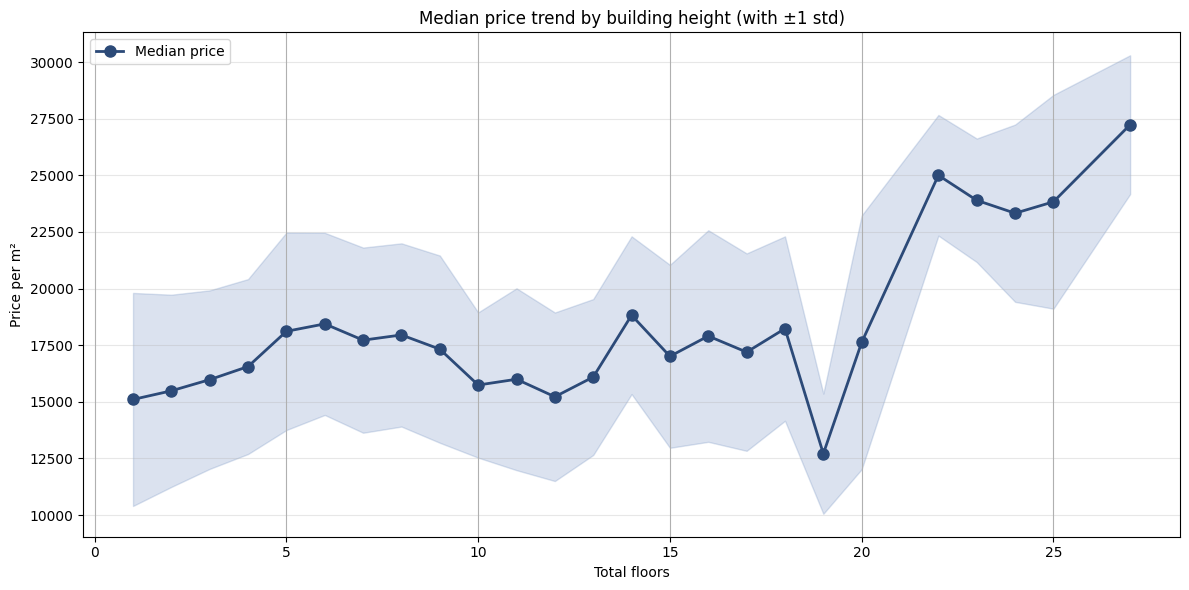



Indicators of growth rate changes:
Intervals with the largest price increase:
  19–20 floors: 4915.9 PLN/m²/floor
  20–22 floors: 3687.5 PLN/m²/floor
  13–14 floors: 2729.4 PLN/m²/floor
  25–27 floors: 1702.2 PLN/m²/floor
   4– 5 floors: 1556.3 PLN/m²/floor


In [148]:
# Analysis of "cutoff" - where the trend changes
# Median price for each number of floors
floors_price_trend = (
    df_ft
    .groupby("floors_total")["price_per_m2"]
    .agg(["count", "median", "mean", "std"])
    .reset_index()
    .rename(columns={"count": "n"})
)

# Filter only intervals with min 10 observations
floors_price_trend = floors_price_trend[floors_price_trend["n"] >= 10]

print("Price trend by number of floors (min 10 observations):")
display(floors_price_trend)

# Slope analysis in different intervals
print("\n\nSlope analysis (price increase per floor):")
for i in range(len(floors_price_trend) - 1):
    ft1 = floors_price_trend.iloc[i]["floors_total"]
    ft2 = floors_price_trend.iloc[i+1]["floors_total"]
    price1 = floors_price_trend.iloc[i]["median"]
    price2 = floors_price_trend.iloc[i+1]["median"]
    
    slope = (price2 - price1) / (ft2 - ft1)
    
    print(f"{ft1:2.0f}–{ft2:2.0f} floors: median {price1:7.0f} → {price2:7.0f} PLN/m² | increase: {slope:6.1f} PLN/m²/floor")

# Trend visualization
plt.close("all")
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(
    floors_price_trend["floors_total"],
    floors_price_trend["median"],
    marker="o",
    markersize=8,
    linewidth=2,
    color="#2C4A78",
    label="Median price"
)

ax.fill_between(
    floors_price_trend["floors_total"],
    floors_price_trend["median"] - floors_price_trend["std"],
    floors_price_trend["median"] + floors_price_trend["std"],
    alpha=0.2,
    color="#4C72B0"
)

ax.set_xlabel("Total floors")
ax.set_ylabel("Price per m²")
ax.set_title("Median price trend by building height (with ±1 std)")
ax.legend()
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# Find the point where the growth rate changes
print("\n\nIndicators of growth rate changes:")
slopes = []
for i in range(len(floors_price_trend) - 1):
    ft1 = floors_price_trend.iloc[i]["floors_total"]
    ft2 = floors_price_trend.iloc[i+1]["floors_total"]
    price1 = floors_price_trend.iloc[i]["median"]
    price2 = floors_price_trend.iloc[i+1]["median"]
    slope = (price2 - price1) / (ft2 - ft1)
    slopes.append((ft1, ft2, slope))

# Sort by slope - where is the largest increase
slopes_sorted = sorted(slopes, key=lambda x: x[2], reverse=True)
print("Intervals with the largest price increase:")
for ft1, ft2, slope in slopes_sorted[:5]:
    print(f"  {ft1:2.0f}–{ft2:2.0f} floors: {slope:6.1f} PLN/m²/floor")

Distribution of observations by category:
height_category
Mid (3–20)       20530
Very low (<3)     1342
High (>20)         119
Name: count, dtype: int64


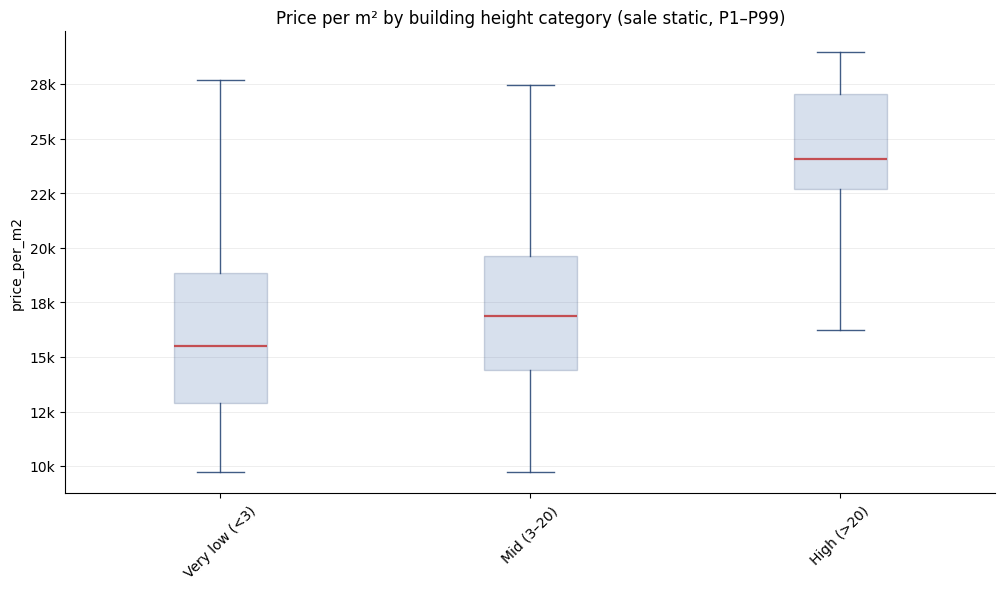

In [151]:
# Box plot comparing 3 building height categories
df_categories = df_view.dropna(subset=["floors_total"]).copy()

# Categorization: <3, 3-20, >20
def categorize_height(floors):
    if floors < 3:
        return "Very low (<3)"
    elif floors <= 20:
        return "Mid (3–20)"
    else:
        return "High (>20)"

df_categories["height_category"] = df_categories["floors_total"].apply(categorize_height)

# Count observations in each category
print("Distribution of observations by category:")
print(df_categories["height_category"].value_counts())

plt.close("all")
plot_box_by_category(
    df_categories,
    y_col="price_per_m2",
    category_col="height_category",
    order=["Very low (<3)", "Mid (3–20)", "High (>20)"],
    bounds=bounds,
    title="Price per m² by building height category (sale static, P1–P99)",
)



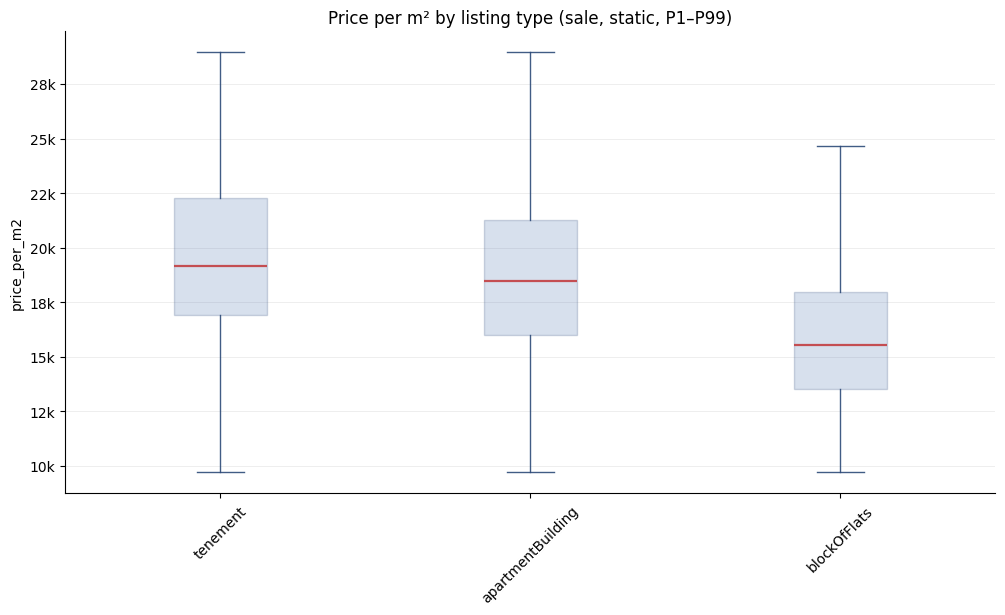

In [153]:
plt.close("all")

type_order = (
    df_view.groupby("listing_type")["price_per_m2"]
    .median()
    .sort_values(ascending=False)
    .index
    .tolist()
)

plot_box_by_category(
    df_view,
    y_col="price_per_m2",
    category_col="listing_type",
    order=type_order,
    bounds=bounds,
    title="Price per m² by listing type (sale, static, P1–P99)",
)


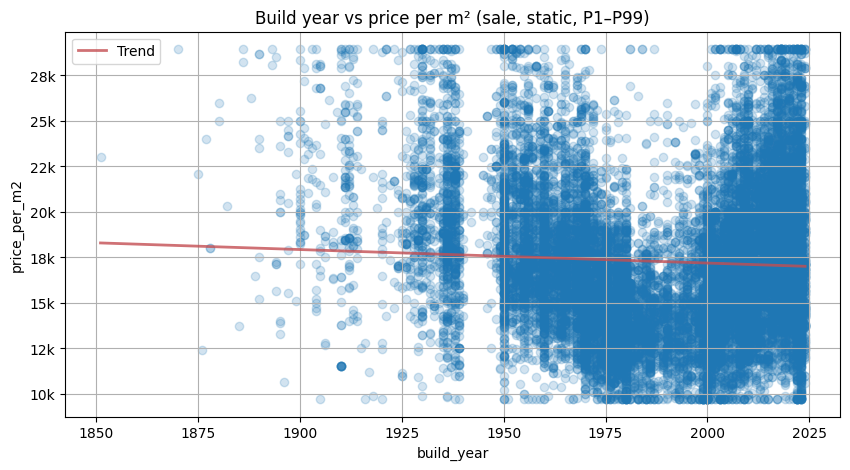

In [190]:
plt.close("all")

plot_scatter(
    df_view[df_view["build_year"].notna()],
    x_col="build_year",
    y_col="price_per_m2",
    bounds=bounds,
    trendline=True,
    title="Build year vs price per m² (sale, static, P1–P99)",
)


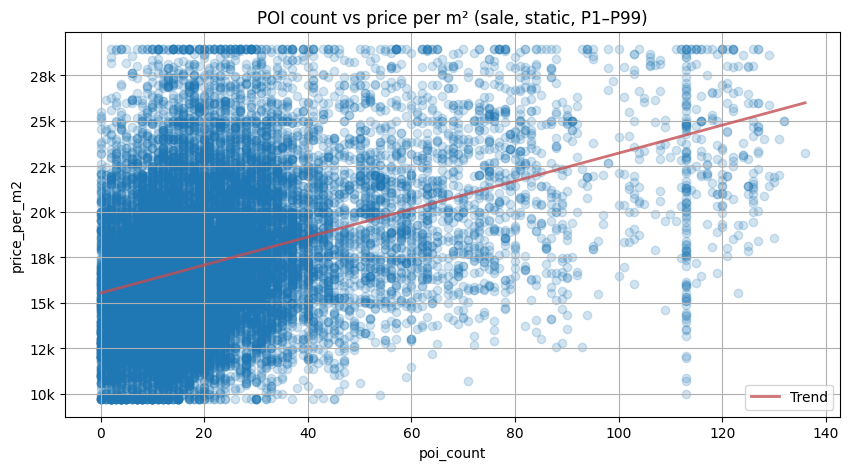

In [193]:
plt.close("all")

plot_scatter(
    df_view,
    x_col="poi_count",
    y_col="price_per_m2",
    bounds=bounds,
    trendline = True,
    title="POI count vs price per m² (sale, static, P1–P99)",
)


In [197]:
df_view.select_dtypes(include="number").corr(method="spearman")


,area_m2,lat,lon,centre_distance,poi_count,school_distance,clinic_distance,post_office_distance,kindergarten_distance,restaurant_distance,college_distance,pharmacy_distance,price,price_per_m2,rooms,floor,floors_total,build_year
area_m2,1.000000,-0.115854,0.080292,0.158768,-0.096382,0.122035,0.056888,0.055354,0.073108,0.021394,0.112381,0.062474,0.773123,-0.188499,0.825754,-0.064294,-0.123299,0.176820
lat,-0.115854,1.000000,-0.192363,-0.043679,0.005052,-0.044760,0.081728,0.016999,-0.095300,0.128475,-0.196688,0.006064,-0.240577,-0.204092,-0.064954,0.022186,-0.019634,-0.052939
lon,0.080292,-0.192363,1.000000,0.125699,0.044995,-0.047868,0.073403,-0.011221,0.101404,-0.001908,-0.091253,-0.005457,0.066197,-0.010482,0.051232,-0.086212,-0.123426,-0.036857
centre_distance,0.158768,-0.043679,0.125699,1.000000,-0.605659,0.420574,0.518216,0.284730,0.131451,0.400506,0.584208,0.300183,-0.146805,-0.481184,0.137153,-0.126329,-0.220120,0.471867
poi_count,-0.096382,0.005052,0.044995,-0.605659,1.000000,-0.544956,-0.595086,-0.559324,-0.308214,-0.581560,-0.644753,-0.555408,0.129727,0.354206,-0.105151,0.096788,0.165168,-0.471546
school_distance,0.122035,-0.044760,-0.047868,0.420574,-0.544956,1.000000,0.366838,0.388833,0.273395,0.234130,0.431307,0.331007,0.039960,-0.118046,0.078724,-0.081352,-0.119874,0.464493
clinic_distance,0.056888,0.081728,0.073403,0.518216,-0.595086,0.366838,1.000000,0.320648,0.179687,0.355197,0.474527,0.332631,-0.148341,-0.320996,0.068435,-0.128052,-0.202369,0.308579
post_office_distance,0.055354,0.016999,-0.011221,0.284730,-0.559324,0.388833,0.320648,1.000000,0.240495,0.359456,0.332129,0.406540,-0.008701,-0.096006,0.044460,-0.077107,-0.127626,0.362838
kindergarten_distance,0.073108,-0.095300,0.101404,0.131451,-0.308214,0.273395,0.179687,0.240495,1.000000,0.155287,0.190997,0.226939,0.043278,-0.033416,0.060792,-0.056418,-0.056025,0.163240
restaurant_distance,0.021394,0.128475,-0.001908,0.400506,-0.581560,0.234130,0.355197,0.359456,0.155287,1.000000,0.329859,0.413282,-0.189150,-0.334486,0.064980,-0.061134,-0.121265,0.175004


In [199]:
df_view.select_dtypes(include="number") \
       .corr(method="spearman")["price_per_m2"] \
       .sort_values(ascending=False)


price_per_m2             1.000000
price                    0.418730
poi_count                0.354206
floors_total             0.073445
build_year               0.013989
floor                    0.009741
lon                     -0.010482
kindergarten_distance   -0.033416
post_office_distance    -0.096006
pharmacy_distance       -0.114303
school_distance         -0.118046
area_m2                 -0.188499
lat                     -0.204092
rooms                   -0.228841
college_distance        -0.297601
clinic_distance         -0.320996
restaurant_distance     -0.334486
centre_distance         -0.481184
Name: price_per_m2, dtype: float64

In [201]:
plt.close("all")

plot_scatter(
    df_view,
    x_col="area_m2",
    y_col="price",""
    bounds=bounds,
    trendline=True,
    title="Total price vs area (sale, static, P1–P99)",
)


SyntaxError: invalid syntax. Perhaps you forgot a comma? (2040303728.py, line 6)